<a href="https://colab.research.google.com/github/vs-152/FL-Contributions-Incentives-Project/blob/main/ISO_CIFAR10_OR_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─────────────────────────────────────────────────────────────
#  Imports
# ─────────────────────────────────────────────────────────────
import os
import copy
import time
import glob
import shutil
import tempfile
from itertools import chain, combinations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.special import comb
import matplotlib.pyplot as plt
from tqdm import tqdm
import nibabel as nib
import pulp
import onnxruntime
import random

# ─────────────────────────────────────────────────────────────
#  MONAI
# ─────────────────────────────────────────────────────────────
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.networks.nets import SegResNet
from monai.apps import DecathlonDataset
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    ScaleIntensityd,
    Spacingd,
    SelectItemsd
)

# ─────────────────────────────────────────────────────────────
#  Custom Modules
# ─────────────────────────────────────────────────────────────
from utils import *

# ─────────────────────────────────────────────────────────────
#  Device & Setup
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print_config()
set_determinism(seed=0)


2026-03-12 12:25:55.059159802 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


MONAI version: 1.6.dev2542
Numpy version: 2.1.2
Pytorch version: 2.8.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 612f3dd3cba4d73cfcea4b5329079e20aa31523d
MONAI __file__: /home/<username>/miniconda3/envs/m_quant_py310/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.4
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.3
Pillow version: 11.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.23.0+cu126
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.2
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For d

In [2]:
# Corrected conversion for FeTS labels
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    FeTS/BraTS label mapping (ints on disk): 0=background, 1=NCR/NET, 2=edema, 4=enhancing (ET)
    Build 3-channel multi-label [TC, WT, ET]:
      TC = (label==1) OR (label==4)
      WT = (label==1) OR (label==2) OR (label==4)
      ET = (label==4)
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            lab = d[key]
            tc = torch.logical_or(lab == 1, lab == 4)
            wt = torch.logical_or(torch.logical_or(lab == 1, lab == 2), lab == 4)
            et = (lab == 4)
            d[key] = torch.stack([tc, wt, et], dim=0).float()
        return d

simclr_base_transform = Compose(
    [
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys="image"),
        Orientationd(keys="image", axcodes="RAS"),
        Spacingd(
            keys="image",
            pixdim=(1.0, 1.0, 1.0),
            mode="bilinear",
        ),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------
# 0. paths & meta-data (unchanged) ---------------------------
# -----------------------------------------------------------
BRATS_DIR = "/mnt/d/Datasets/FETS_data/MICCAI_FeTS2022_TrainingData"
CSV_PATH  = f"{BRATS_DIR}/partitioning_1.csv"
MODALITIES = ["flair", "t1", "t1ce", "t2"]
LABEL_KEY  = "seg"

# -----------------------------------------------------------
# 1. read partition file  ➜  { id : [subjects] } ------------
# -----------------------------------------------------------
part_df = pd.read_csv(CSV_PATH)

# --- compute subject counts per site -----------------------
site_counts = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .nunique()
)

TOP_K = 6  # keep 6 most populated sites for training

# site IDs for training (top-K by subject count)
TRAIN_CENTRES = set(
    site_counts.sort_values(ascending=False)
               .head(TOP_K)
               .index.tolist()
)

# everything else is validation
VAL_CENTRES = set(site_counts.index) - TRAIN_CENTRES

print("Train centres (top 6 by subject count):")
print(site_counts.loc[sorted(TRAIN_CENTRES)])
print("\nValidation centres (remaining):")
print(site_counts.loc[sorted(VAL_CENTRES)])

# map centre → list of subject IDs
partition_map = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .apply(list).to_dict()
)

# split once, reuse everywhere
train_partitions = {
    cid: sids for cid, sids in partition_map.items()
    if cid in TRAIN_CENTRES
}
val_subjects = sum((partition_map[cid] for cid in VAL_CENTRES), [])


# -----------------------------------------------------------
# 2. helper to build MONAI-style record dicts ----------------
# -----------------------------------------------------------
def build_simclr_records(subject_ids):
    recs = []
    for sid in subject_ids:
        sdir = f"{BRATS_DIR}/{sid}"
        images = [f"{sdir}/{sid}_{m}.nii.gz" for m in MODALITIES]
        recs.append({"image": images})
    return recs

# -----------------------------------------------------------
# 3. MONAI CacheDatasets ------------------------------------
# -----------------------------------------------------------
FRAC, SEED = 1, 42   # FRAC for subsampling within each site
rng = random.Random(SEED)

simclr_base_datasets = {}

for cid, subj_ids in train_partitions.items():
    simclr_base_datasets[cid] = CacheDataset(
        build_simclr_records(subj_ids),
        transform=simclr_base_transform,
        cache_rate=1,
    )

Train centres (top 6 by subject count):
Partition_ID
1     511
4      47
6      34
13     35
18    382
21     35
Name: Subject_ID, dtype: int64

Validation centres (remaining):
Partition_ID
2      6
3     15
5     22
7     12
8      8
9      4
10     8
11    14
12    11
14     6
15    13
16    30
17     9
19     4
20    33
22     7
23     5
Name: Subject_ID, dtype: int64


Loading dataset: 100%|██████████████████████████████████████████████████████████████████| 35/35 [03:17<00:00,  5.63s/it]


# SimCLR data handling

In [4]:
# ─────────────────────────────────────────────────────────────
#  SimCLR Contrastive Transform (image only)
# ─────────────────────────────────────────────────────────────

from monai.transforms import RandRotate90d, RandGaussianNoised

simclr_2d_transform = Compose(
    [
        EnsureTyped(keys="image"),
        RandFlipd(keys="image", prob=0.5, spatial_axis=0),
        RandFlipd(keys="image", prob=0.5, spatial_axis=1),
        RandRotate90d(keys="image", prob=0.5),
        # RandScaleIntensityd(keys="image", factors=0.1, prob=0.8),
        # RandShiftIntensityd(keys="image", offsets=0.1, prob=0.8),
        # RandGaussianNoised(keys="image", prob=0.5),
    ]
)

class SimCLR2DDataset(Dataset):
    def __init__(self, monai_dataset, transform, slices_per_volume=20):
        self.dataset = monai_dataset
        self.transform = transform
        self.slices_per_volume = slices_per_volume

    def __len__(self):
        return len(self.dataset) * self.slices_per_volume

    def __getitem__(self, idx):
        # map idx back to volume index
        vol_idx = idx % len(self.dataset)
        data = self.dataset[vol_idx]

        img = data["image"]  # [C, H, W, D]

        depth = img.shape[-1]
        z = torch.randint(0, depth, (1,)).item()
        slice_2d = img[..., z]

        slice_dict = {"image": slice_2d}

        view1 = self.transform(slice_dict)["image"]
        view2 = self.transform(slice_dict)["image"]

        return view1, view2
        
simclr_train_datasets = {
    cid: SimCLR2DDataset(ds, simclr_2d_transform, slices_per_volume=20)
    for cid, ds in simclr_base_datasets.items()
}

from torch.utils.data import ConcatDataset

simclr_pooled_dataset = ConcatDataset(
    list(simclr_train_datasets.values())
)

simclr_loader = DataLoader(
    simclr_pooled_dataset,
    batch_size=32,   # now we can go bigger
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

In [5]:
v1, v2 = next(iter(simclr_loader))
print(v1.shape, v2.shape)
print("Total SimCLR samples:", len(simclr_pooled_dataset))
print("Batches per epoch:", len(simclr_loader))

torch.Size([32, 4, 240, 240]) torch.Size([32, 4, 240, 240])
Total SimCLR samples: 20880
Batches per epoch: 653


#  SimCLR model

Step 1 — Define Encoder + Projection Head

In [6]:
# ─────────────────────────────────────────────────────────────
#  SimCLR Model (2D)
# ─────────────────────────────────────────────────────────────
from monai.networks.nets import resnet

class SimCLR2D(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()

        # 2D ResNet18
        self.encoder = resnet.resnet18(
            spatial_dims=2,
            n_input_channels=4,  # 4 MRI modalities
            num_classes=512
        )

        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


model = SimCLR2D().to(device)

Step 2 — Implement NT-Xent Loss

In [7]:
import torch.nn.functional as F

def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    representations = torch.cat([z1, z2], dim=0)

    similarity_matrix = torch.matmul(representations, representations.T)

    labels = torch.arange(batch_size).to(device)
    labels = torch.cat([labels, labels], dim=0)

    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(device)
    similarity_matrix = similarity_matrix[~mask].view(labels.shape[0], -1)

    positives = torch.cat([
        torch.sum(z1 * z2, dim=1),
        torch.sum(z2 * z1, dim=1)
    ], dim=0)

    logits = similarity_matrix / temperature
    positives = positives / temperature

    loss = -torch.log(
        torch.exp(positives) /
        torch.sum(torch.exp(logits), dim=1)
    )

    return loss.mean()

Step 3 - Training Loop - Comment out to just run visuals

In [8]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=50
# )

# epochs = 50
# best_loss = float("inf")

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for v1, v2 in tqdm(simclr_loader):
#         v1 = v1.to(device)
#         v2 = v2.to(device)

#         _, z1 = model(v1)
#         _, z2 = model(v2)

#         loss = nt_xent_loss(z1, z2)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     # ---- end of epoch ----
#     scheduler.step()

#     epoch_loss = total_loss / len(simclr_loader)

#     print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

#     if epoch_loss < best_loss:
#         best_loss = epoch_loss
#         torch.save(model.state_dict(), "./simclr_models/simclr_2d_best.pt")

In [9]:
model.load_state_dict(torch.load("./simclr_models/simclr_2d_best.pt"))
model.eval()

SimCLR2D(
  (encoder): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): ResNetBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResNetBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

# Build Per-Site Embedding Extractor

In [10]:
def extract_site_embeddings(site_dataset, model, device):
    loader = DataLoader(
        site_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    all_embeddings = []

    with torch.no_grad():
        for v1, _ in loader:   # only need one view
            v1 = v1.to(device)
            h, _ = model(v1)
            all_embeddings.append(h.cpu())

    return torch.cat(all_embeddings, dim=0)

site_embeddings = {}

for cid, dataset in simclr_train_datasets.items():
    print(f"Extracting embeddings for site {cid}")
    site_embeddings[cid] = extract_site_embeddings(dataset, model, device)

Extracting embeddings for site 1
Extracting embeddings for site 4
Extracting embeddings for site 6
Extracting embeddings for site 13
Extracting embeddings for site 18
Extracting embeddings for site 21


Explained variance ratio (first 10 components):
[0.2    0.1371 0.0946 0.0871 0.0835 0.0767 0.057  0.0528 0.0444 0.0358]


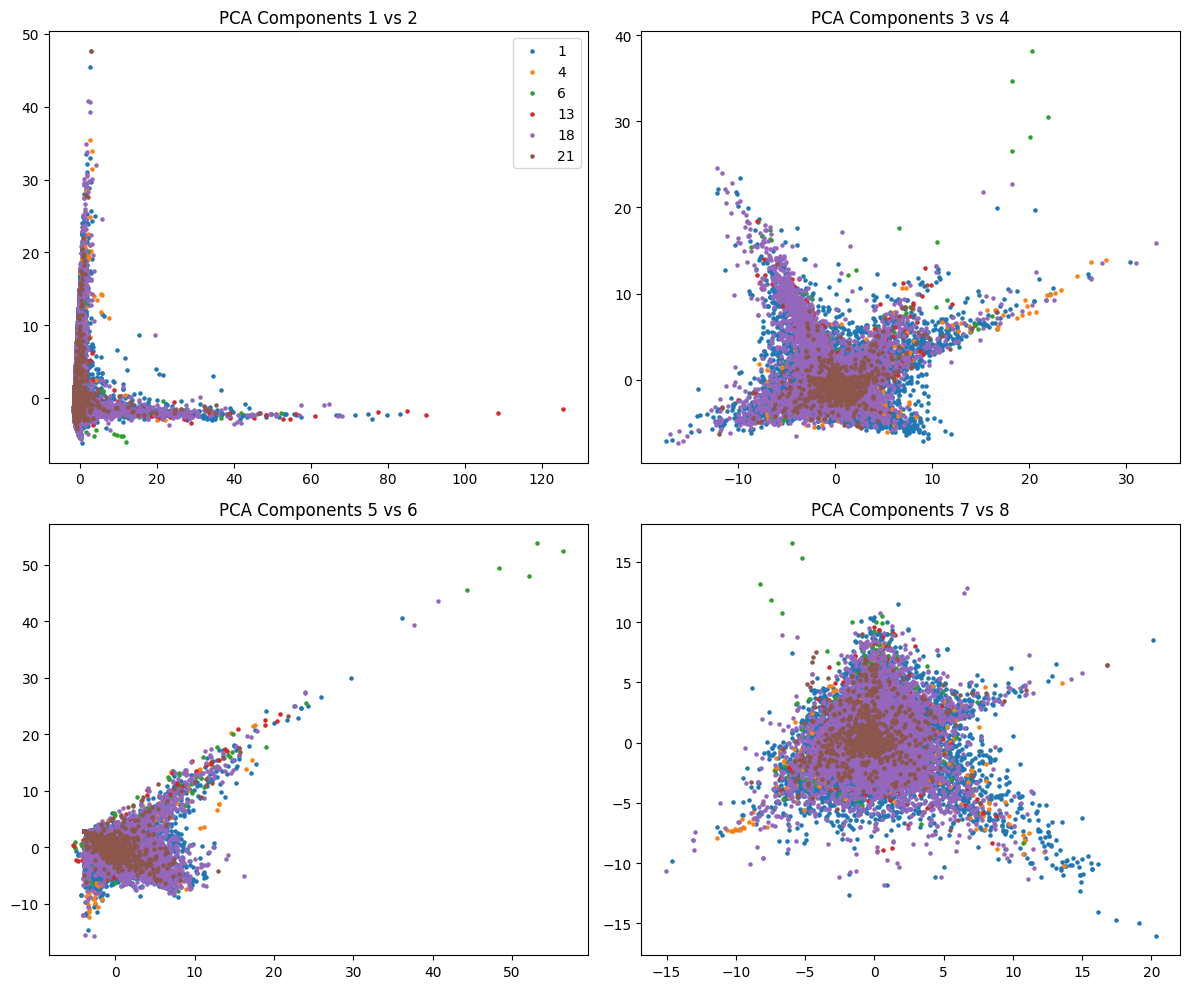

In [11]:
# ─────────────────────────────────────────────────────────────
#  PCA Exploration (different component pairs)
# ─────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- rebuild all_embs + labels if not already in memory ---
all_embs = []
labels = []
site_ids = list(simclr_train_datasets.keys())

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid]   # tensor [N, 512]
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

# --- PCA ---
pca = PCA(n_components=10)
proj = pca.fit_transform(all_embs)

print("Explained variance ratio (first 10 components):")
print(np.round(pca.explained_variance_ratio_, 4))

# --- Plot different component pairs ---
pairs = [(0,1), (2,3), (4,5), (6,7)]

plt.figure(figsize=(12,10))
for idx, (i, j) in enumerate(pairs, 1):
    plt.subplot(2, 2, idx)
    for k, cid in enumerate(site_ids):
        mask = labels == k
        plt.scatter(proj[mask, i], proj[mask, j], s=5, label=str(cid))
    plt.title(f"PCA Components {i+1} vs {j+1}")
    if idx == 1:
        plt.legend()
plt.tight_layout()
plt.savefig("./plots/pca_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

Explained variance ratio (first 10 components):
[0.2    0.1371 0.0946 0.0871 0.0835 0.0767 0.057  0.0528 0.0444 0.0358]


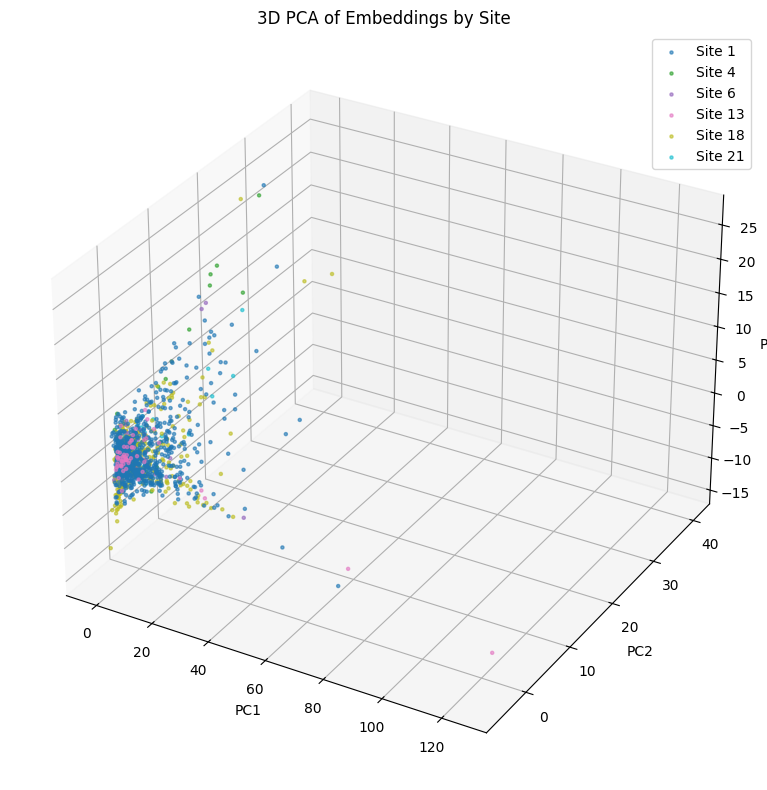

In [36]:
# ─────────────────────────────────────────────────────────────
#  3D PCA Plot (PC1, PC2, PC3) colored by site
# ─────────────────────────────────────────────────────────────

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d import Axes3D

# --- rebuild embeddings ---
all_embs = []
labels = []
site_ids = list(site_embeddings.keys())

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid]
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

# --- PCA ---
pca = PCA(n_components=10)
proj = pca.fit_transform(all_embs)

print("Explained variance ratio (first 10 components):")
print(np.round(pca.explained_variance_ratio_, 4))

# --- optional subsampling to avoid overplotting ---
max_points = 2000
if proj.shape[0] > max_points:
    idx = np.random.choice(proj.shape[0], max_points, replace=False)
    proj_plot = proj[idx]
    labels_plot = labels[idx]
else:
    proj_plot = proj
    labels_plot = labels

# --- color map ---
colors = plt.cm.tab10(np.linspace(0, 1, len(site_ids)))

# --- 3D plot ---
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for i, cid in enumerate(site_ids):

    mask = labels_plot == i

    ax.scatter(
        proj_plot[mask, 0],
        proj_plot[mask, 1],
        proj_plot[mask, 2],
        s=5,
        color=colors[i],
        alpha=0.6,
        label=f"Site {cid}"
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("3D PCA of Embeddings by Site")

ax.legend()

plt.tight_layout()

plt.savefig(
    "./plots/pca_3d_pc1_pc2_pc3.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Explained variance ratio (first 4 components):
[0.2    0.1371 0.0946 0.0871]


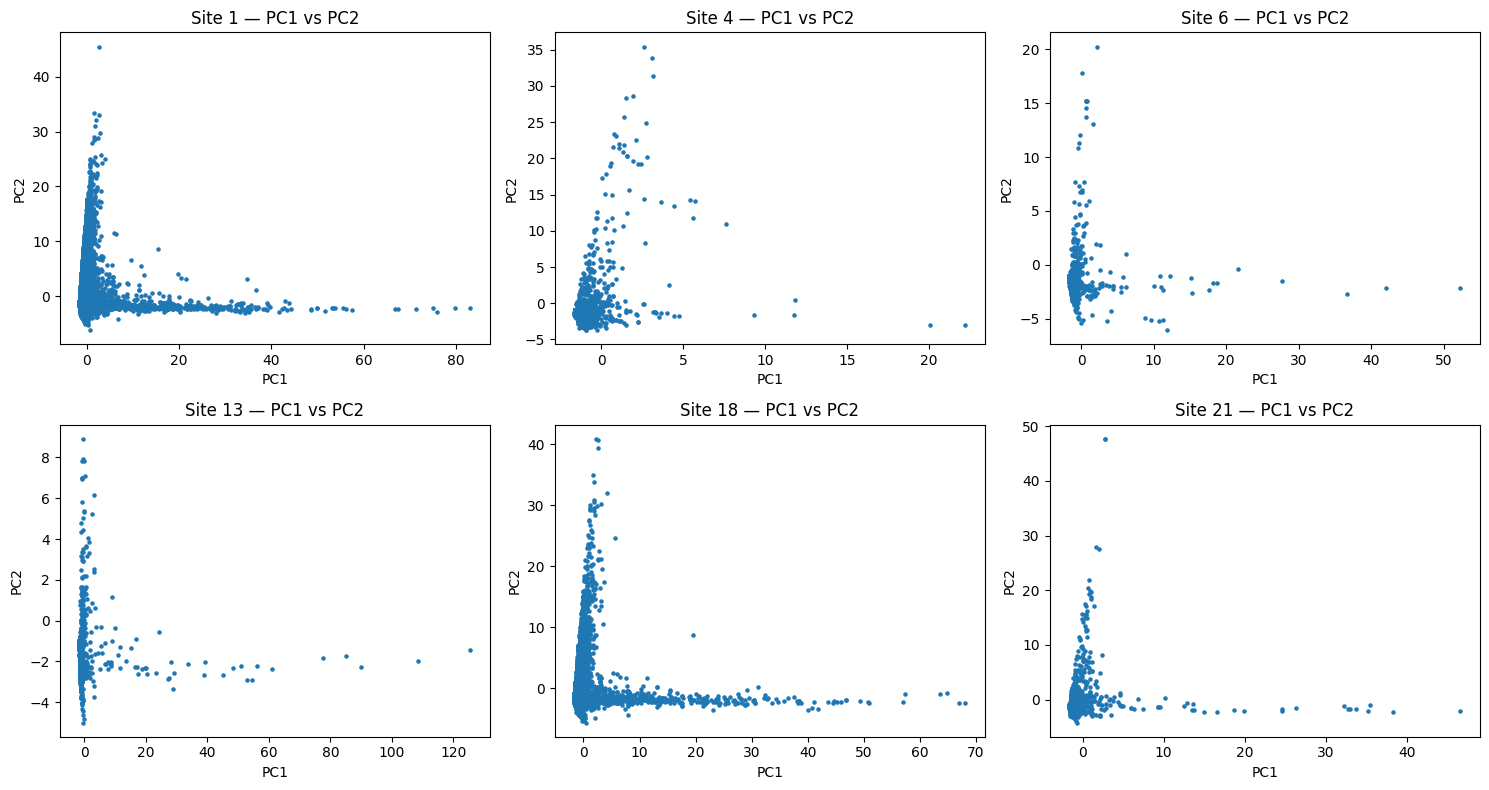

In [29]:
# ─────────────────────────────────────────────────────────────
#  PCA Components 1 & 2 — Separate Plot Per Site
# ─────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# Rebuild embeddings matrix if needed
all_embs = []
labels = []
site_ids = list(site_embeddings.keys())

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid]
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

# PCA
pca = PCA(n_components=4)
proj = pca.fit_transform(all_embs)

print("Explained variance ratio (first 4 components):")
print(np.round(pca.explained_variance_ratio_, 4))

# Plot PC1 vs PC2
n_sites = len(site_ids)
cols = 3
rows = int(np.ceil(n_sites / cols))

plt.figure(figsize=(5 * cols, 4 * rows))

for i, cid in enumerate(site_ids):
    plt.subplot(rows, cols, i + 1)
    mask = labels == i
    plt.scatter(proj[mask, 0], proj[mask, 1], s=5)
    plt.title(f"Site {cid} — PC1 vs PC2")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

plt.tight_layout()
plt.savefig("./plots/pca_pc1_pc2_per_site.pdf", format="pdf", bbox_inches="tight")
plt.show()

Explained variance ratio (first 4 components):
[0.2    0.1371 0.0946 0.0871]


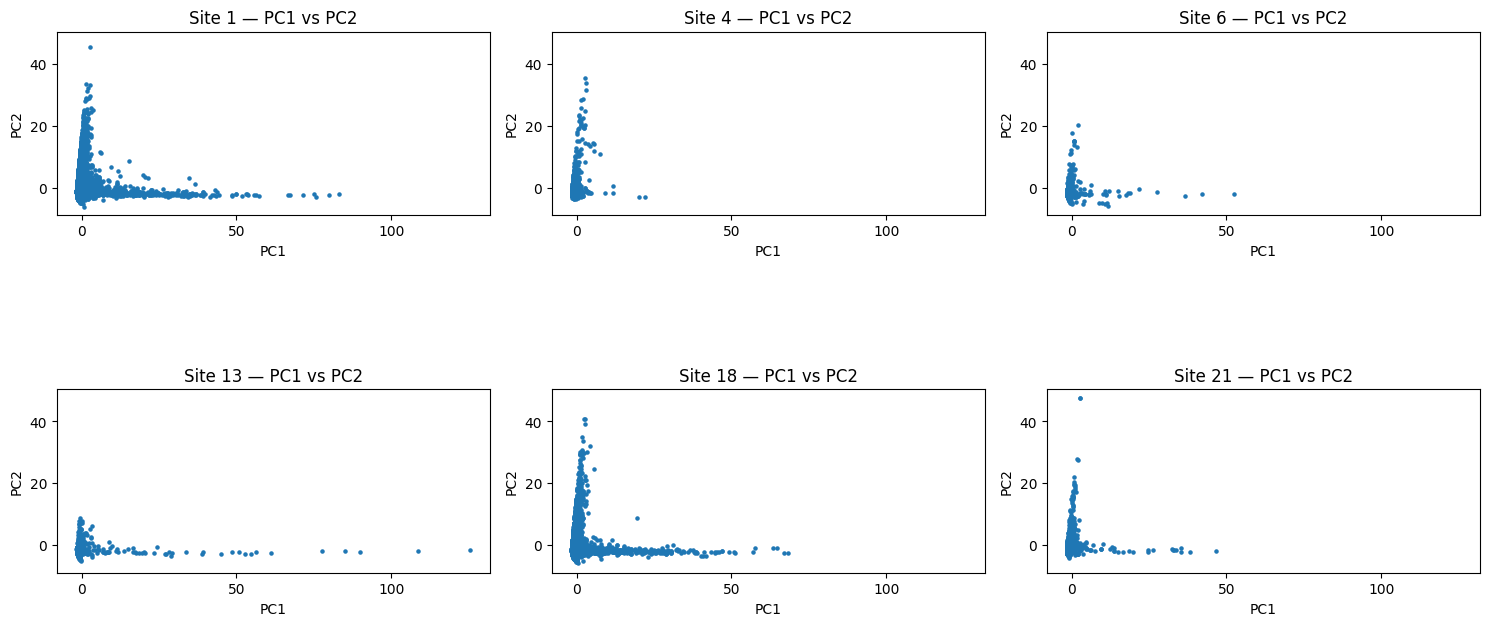

In [42]:
# ─────────────────────────────────────────────────────────────
#  PCA Components 1 & 2 — Separate Plot Per Site (Shared Scale)
# ─────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# Rebuild embeddings matrix if needed
all_embs = []
labels = []
site_ids = list(site_embeddings.keys())

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid]
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

# PCA
pca = PCA(n_components=4)
proj = pca.fit_transform(all_embs)

print("Explained variance ratio (first 4 components):")
print(np.round(pca.explained_variance_ratio_, 4))


# ── Compute global axis limits (no symmetry) ──────────────────
x_min, x_max = proj[:, 0].min(), proj[:, 0].max()
y_min, y_max = proj[:, 1].min(), proj[:, 1].max()

# add small padding so points aren't on borders
pad_x = 0.05 * (x_max - x_min)
pad_y = 0.05 * (y_max - y_min)

x_lim = (x_min - pad_x, x_max + pad_x)
y_lim = (y_min - pad_y, y_max + pad_y)


# ── Plot PC1 vs PC2 ───────────────────────────────────────────
n_sites = len(site_ids)
cols = 3
rows = int(np.ceil(n_sites / cols))

plt.figure(figsize=(5 * cols, 4 * rows))

for i, cid in enumerate(site_ids):
    plt.subplot(rows, cols, i + 1)

    mask = labels == i
    plt.scatter(proj[mask, 0], proj[mask, 1], s=5)

    plt.title(f"Site {cid} — PC1 vs PC2")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    # Apply identical limits
    plt.xlim(x_lim)
    plt.ylim(y_lim)

    # Same tick count everywhere
    plt.locator_params(axis='x', nbins=5)
    plt.locator_params(axis='y', nbins=5)

    # Make geometry comparable
    plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("./plots/pca_pc1_pc2_per_site.pdf", format="pdf", bbox_inches="tight")
plt.show()

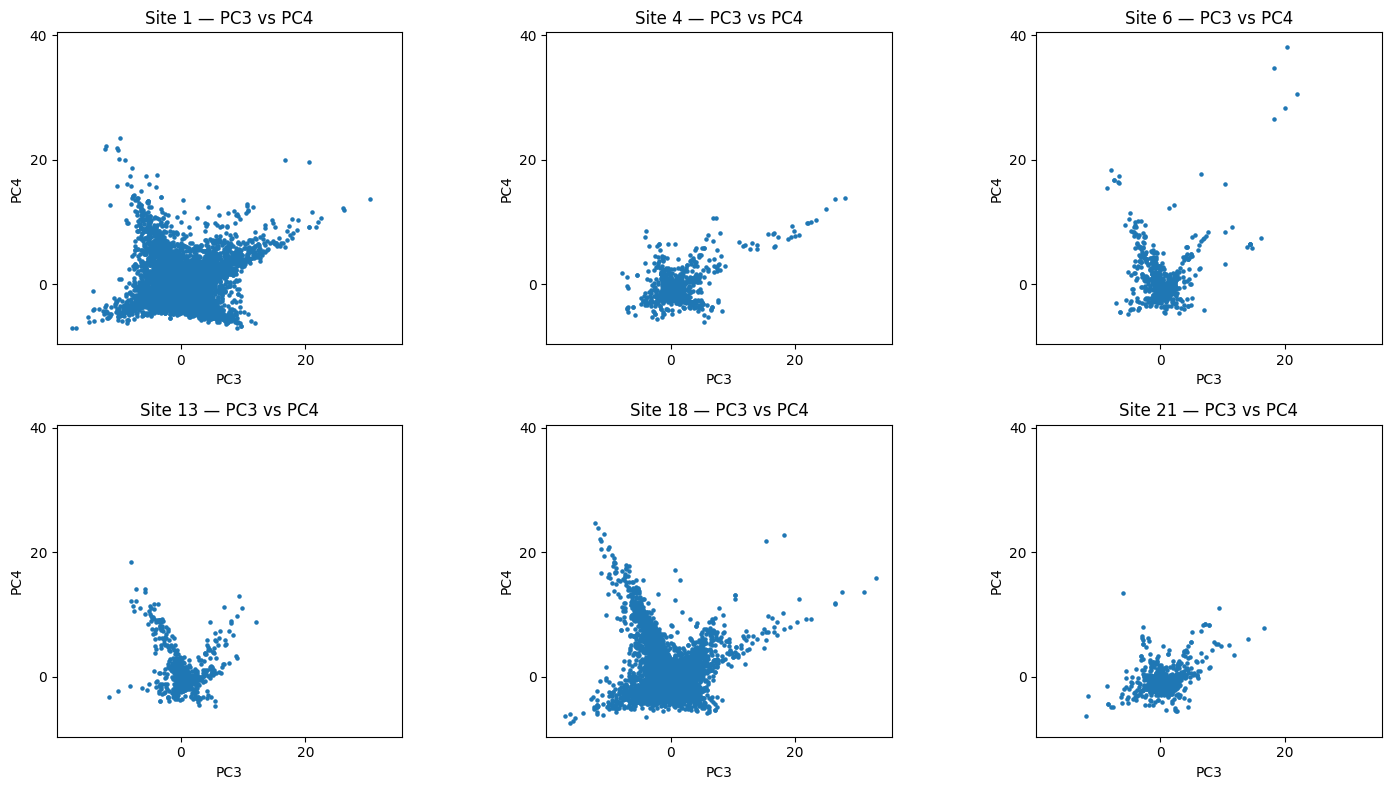

In [40]:
# ─────────────────────────────────────────────────────────────
#  PCA Components 3 & 4 — Separate Plot Per Site (Shared Scale)
# ─────────────────────────────────────────────────────────────

# Compute global axis limits
x_min, x_max = proj[:, 2].min(), proj[:, 2].max()
y_min, y_max = proj[:, 3].min(), proj[:, 3].max()

pad_x = 0.05 * (x_max - x_min)
pad_y = 0.05 * (y_max - y_min)

x_lim = (x_min - pad_x, x_max + pad_x)
y_lim = (y_min - pad_y, y_max + pad_y)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, cid in enumerate(site_ids):
    plt.subplot(rows, cols, i + 1)

    mask = labels == i
    plt.scatter(proj[mask, 2], proj[mask, 3], s=5)

    plt.title(f"Site {cid} — PC3 vs PC4")
    plt.xlabel("PC3")
    plt.ylabel("PC4")

    # identical axes
    plt.xlim(x_lim)
    plt.ylim(y_lim)

    # same tick counts
    plt.locator_params(axis='x', nbins=5)
    plt.locator_params(axis='y', nbins=5)

    # equal geometry
    plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("./plots/pca_pc3_pc4_per_site.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:
all_embs.shape

(20880, 512)

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


Site classification accuracy: 0.6180
Random baseline accuracy: 0.1667


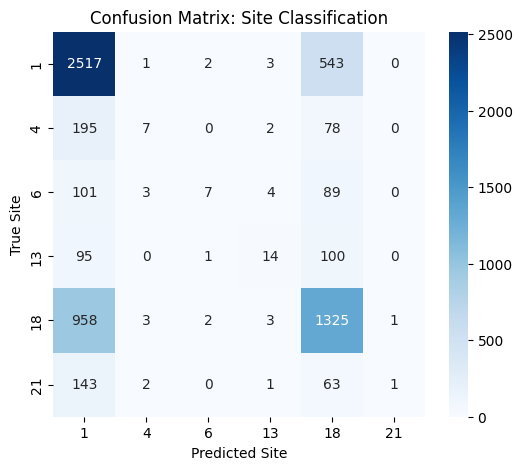

In [13]:
# ─────────────────────────────────────────────────────────────
#  Site Classification from Embeddings
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    all_embs, labels, test_size=0.3, random_state=42, stratify=labels
)

# --- Train classifier ---
clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
clf.fit(X_train, y_train)

# --- Evaluate ---
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Site classification accuracy: {acc:.4f}")
print(f"Random baseline accuracy: {1/len(site_ids):.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=site_ids, yticklabels=site_ids)
plt.title("Confusion Matrix: Site Classification")
plt.xlabel("Predicted Site")
plt.ylabel("True Site")

plt.savefig("./plots/confusion_matrix_site_classification.pdf", format="pdf", bbox_inches="tight")
plt.show()

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


Site classification accuracy (without 1 & 18): 0.4514
Random baseline accuracy: 0.2500


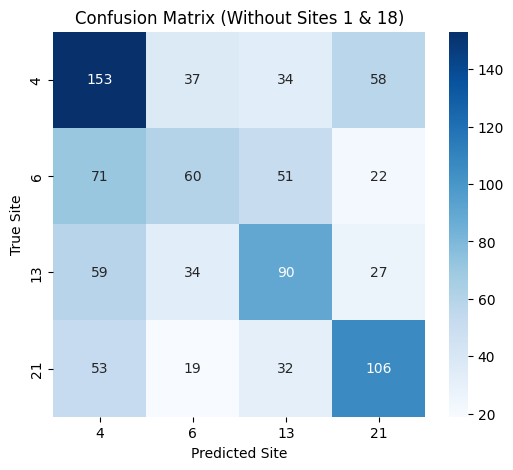

In [14]:
# ─────────────────────────────────────────────────────────────
#  Site Classification (Without Sites 1 and 18)
# ─────────────────────────────────────────────────────────────
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Sites to remove
remove_sites = [1, 18]

# Map site_ids to indices
site_to_idx = {cid: i for i, cid in enumerate(site_ids)}

remove_indices = [site_to_idx[s] for s in remove_sites]

# Keep only samples not in removed sites
mask = ~np.isin(labels, remove_indices)

X_filtered = all_embs[mask]
y_filtered = labels[mask]

# Re-map labels to consecutive integers
unique_labels = np.unique(y_filtered)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_remap = np.array([label_map[l] for l in y_filtered])

filtered_site_ids = [site_ids[i] for i in unique_labels]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_remap, test_size=0.3, random_state=42, stratify=y_remap
)

# Train classifier (balanced to reduce size bias)
clf_small = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    class_weight="balanced"
)
clf_small.fit(X_train, y_train)

# Evaluate
y_pred = clf_small.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Site classification accuracy (without 1 & 18): {acc:.4f}")
print(f"Random baseline accuracy: {1/len(filtered_site_ids):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=filtered_site_ids,
            yticklabels=filtered_site_ids)
plt.title("Confusion Matrix (Without Sites 1 & 18)")
plt.xlabel("Predicted Site")
plt.ylabel("True Site")
plt.show()

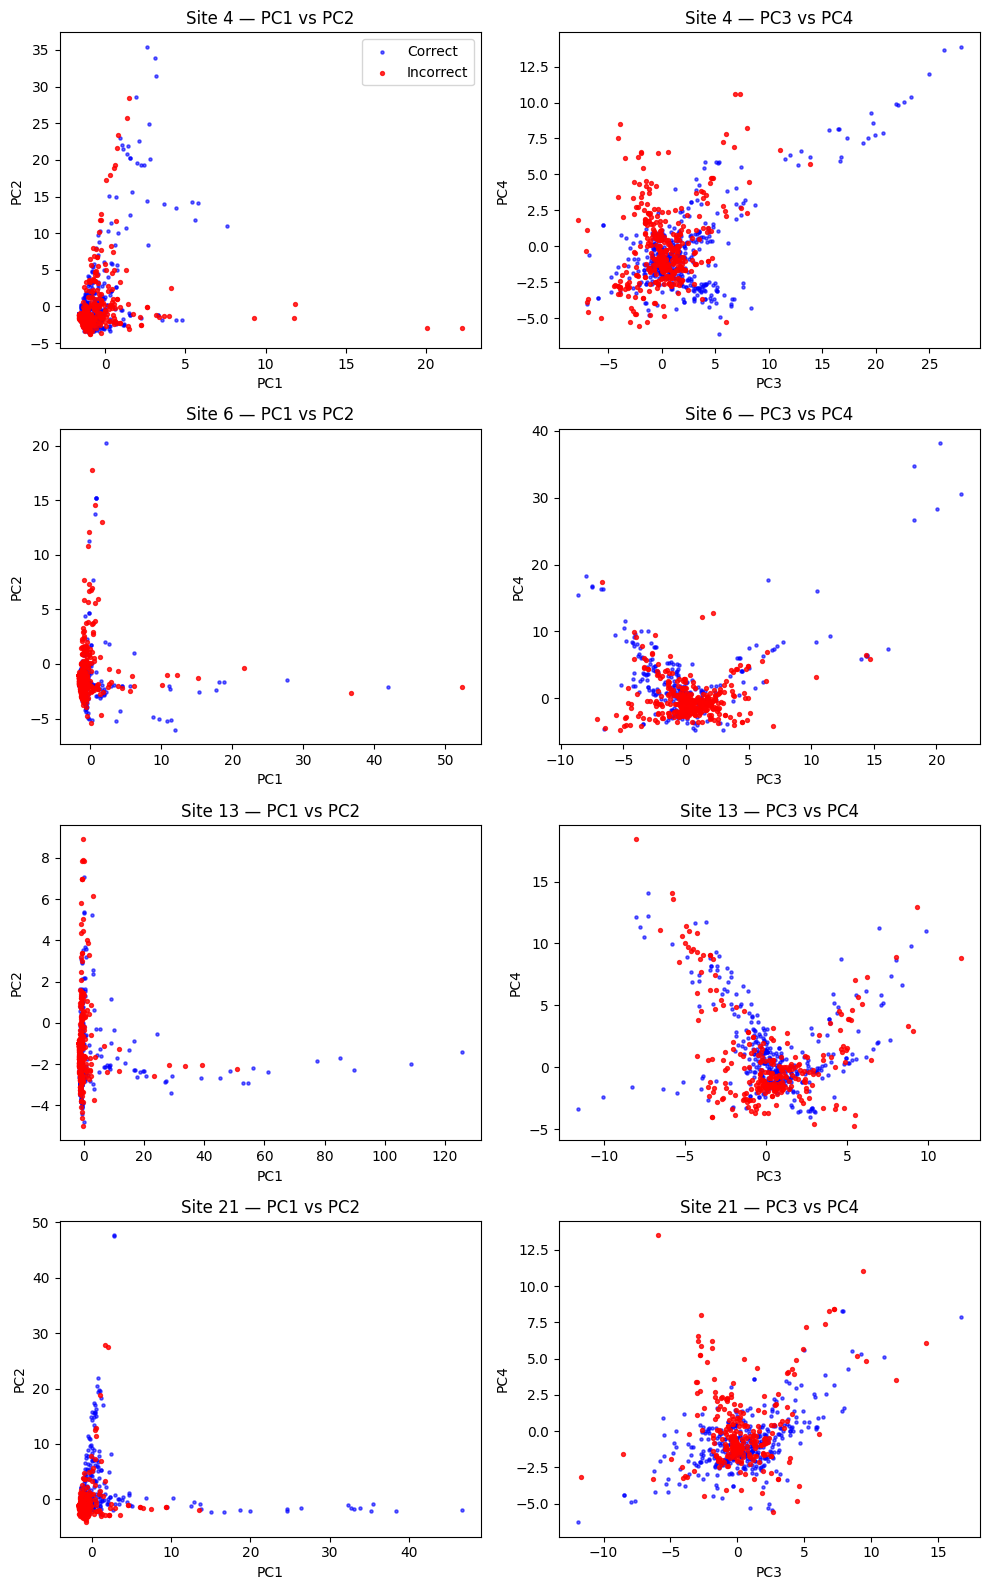

In [37]:
# ─────────────────────────────────────────────────────────────
#  PCA (fit on all sites) — 4x2 layout
#  Rows: sites
#  Col 1: PC1 vs PC2
#  Col 2: PC3 vs PC4
# ─────────────────────────────────────────────────────────────

rows = len(filtered_site_ids)
cols = 2

plt.figure(figsize=(10, 4 * rows))

for i, cid in enumerate(filtered_site_ids):

    site_mask = labels_filtered == site_to_idx[cid]

    # ---- Column 1 : PC1 vs PC2 ----
    plt.subplot(rows, cols, 2*i + 1)

    plt.scatter(
        proj_filtered[site_mask & correct_mask, 0],
        proj_filtered[site_mask & correct_mask, 1],
        s=5,
        color="blue",
        alpha=0.6,
        label="Correct"
    )

    plt.scatter(
        proj_filtered[site_mask & incorrect_mask, 0],
        proj_filtered[site_mask & incorrect_mask, 1],
        s=8,
        color="red",
        alpha=0.8,
        label="Incorrect"
    )

    plt.title(f"Site {cid} — PC1 vs PC2")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    if i == 0:
        plt.legend()

    # ---- Column 2 : PC3 vs PC4 ----
    plt.subplot(rows, cols, 2*i + 2)

    plt.scatter(
        proj_filtered[site_mask & correct_mask, 2],
        proj_filtered[site_mask & correct_mask, 3],
        s=5,
        color="blue",
        alpha=0.6
    )

    plt.scatter(
        proj_filtered[site_mask & incorrect_mask, 2],
        proj_filtered[site_mask & incorrect_mask, 3],
        s=8,
        color="red",
        alpha=0.8
    )

    plt.title(f"Site {cid} — PC3 vs PC4")
    plt.xlabel("PC3")
    plt.ylabel("PC4")

plt.tight_layout()

plt.savefig(
    "./plots/pca_correct_vs_incorrect_4x2.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Explained variance ratio (first 4 components):
[0.2    0.1371 0.0946 0.0871]


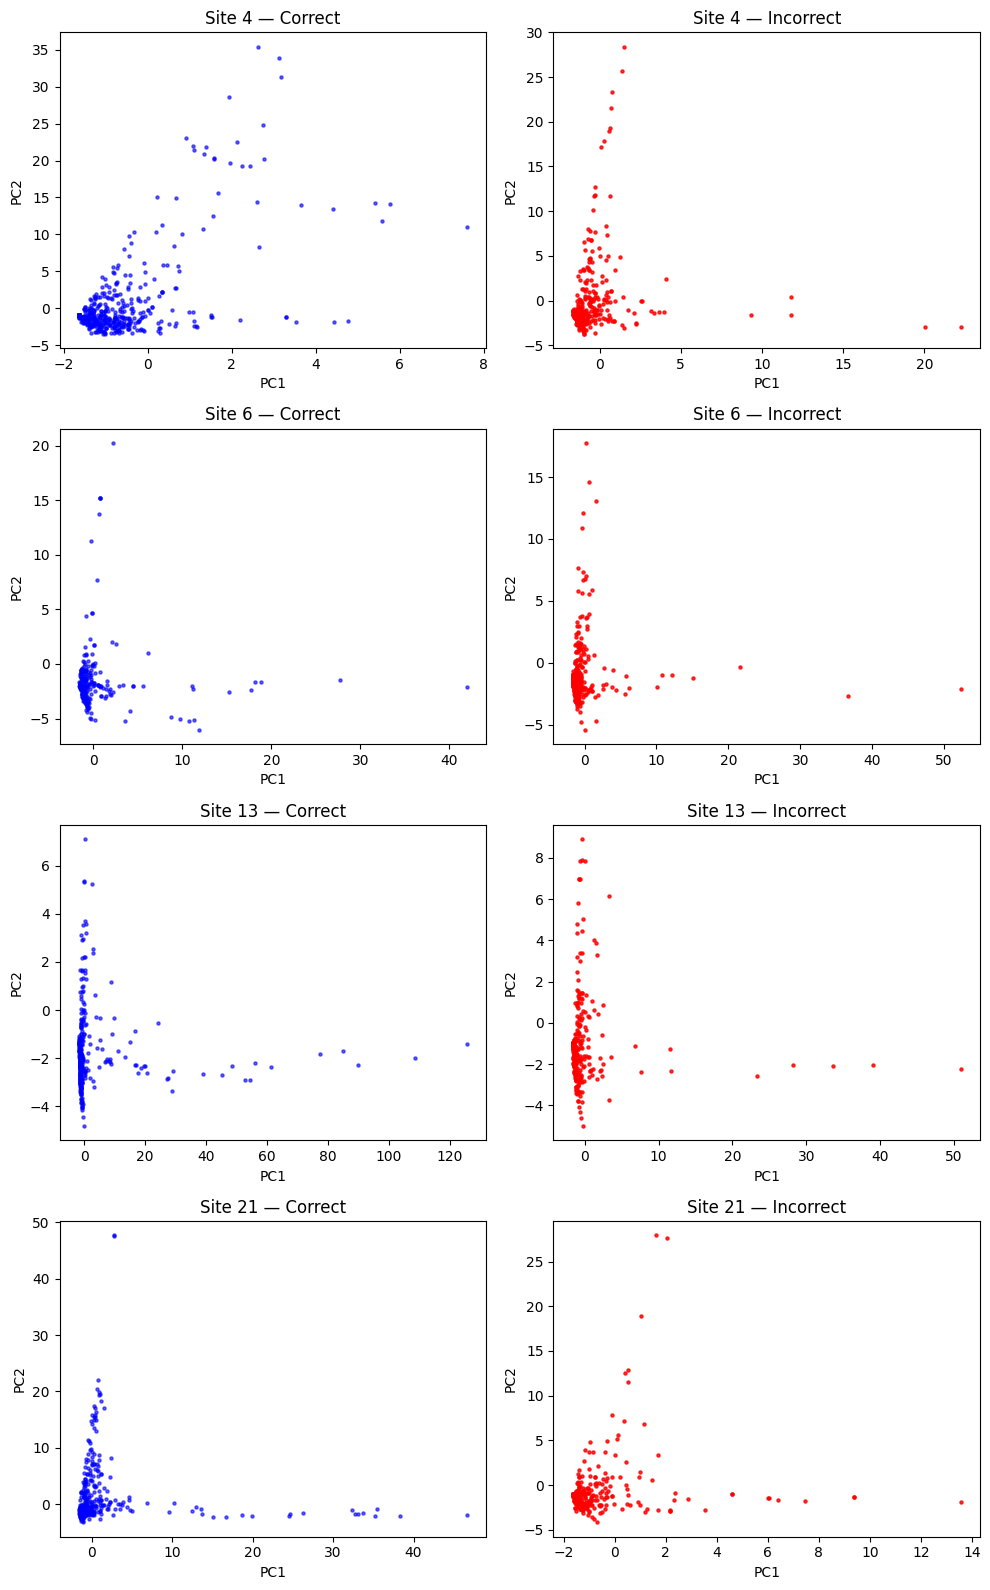

In [31]:
# ─────────────────────────────────────────────────────────────
#  PCA (fit on all sites) but visualize logistic regression sites
# ─────────────────────────────────────────────────────────────

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# ---- rebuild full embedding matrix ----
all_embs = []
labels = []
site_ids = list(site_embeddings.keys())

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid]
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

# ---- PCA on ALL sites ----
pca = PCA(n_components=4)
proj = pca.fit_transform(all_embs)

print("Explained variance ratio (first 4 components):")
print(np.round(pca.explained_variance_ratio_, 4))

# ---- recreate filtering mask used for logistic regression ----
remove_sites = [1, 18]
site_to_idx = {cid: i for i, cid in enumerate(site_ids)}
remove_indices = [site_to_idx[s] for s in remove_sites]

mask = ~np.isin(labels, remove_indices)

proj_filtered = proj[mask]
labels_filtered = labels[mask]

# predictions already computed earlier
# y_remap, correct_mask, incorrect_mask correspond to filtered samples

cols = 2
rows = len(filtered_site_ids)

plt.figure(figsize=(10, 4 * rows))

for i, cid in enumerate(filtered_site_ids):

    site_mask = labels_filtered == site_to_idx[cid]

    # correct
    plt.subplot(rows, cols, 2*i + 1)
    plt.scatter(
        proj_filtered[site_mask & correct_mask, 0],
        proj_filtered[site_mask & correct_mask, 1],
        s=5,
        color="blue",
        alpha=0.6
    )
    plt.title(f"Site {cid} — Correct")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    # incorrect
    plt.subplot(rows, cols, 2*i + 2)
    plt.scatter(
        proj_filtered[site_mask & incorrect_mask, 0],
        proj_filtered[site_mask & incorrect_mask, 1],
        s=5,
        color="red",
        alpha=0.8
    )
    plt.title(f"Site {cid} — Incorrect")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

plt.tight_layout()
plt.savefig("./plots/pca_correct_vs_incorrect_allpcbasis.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

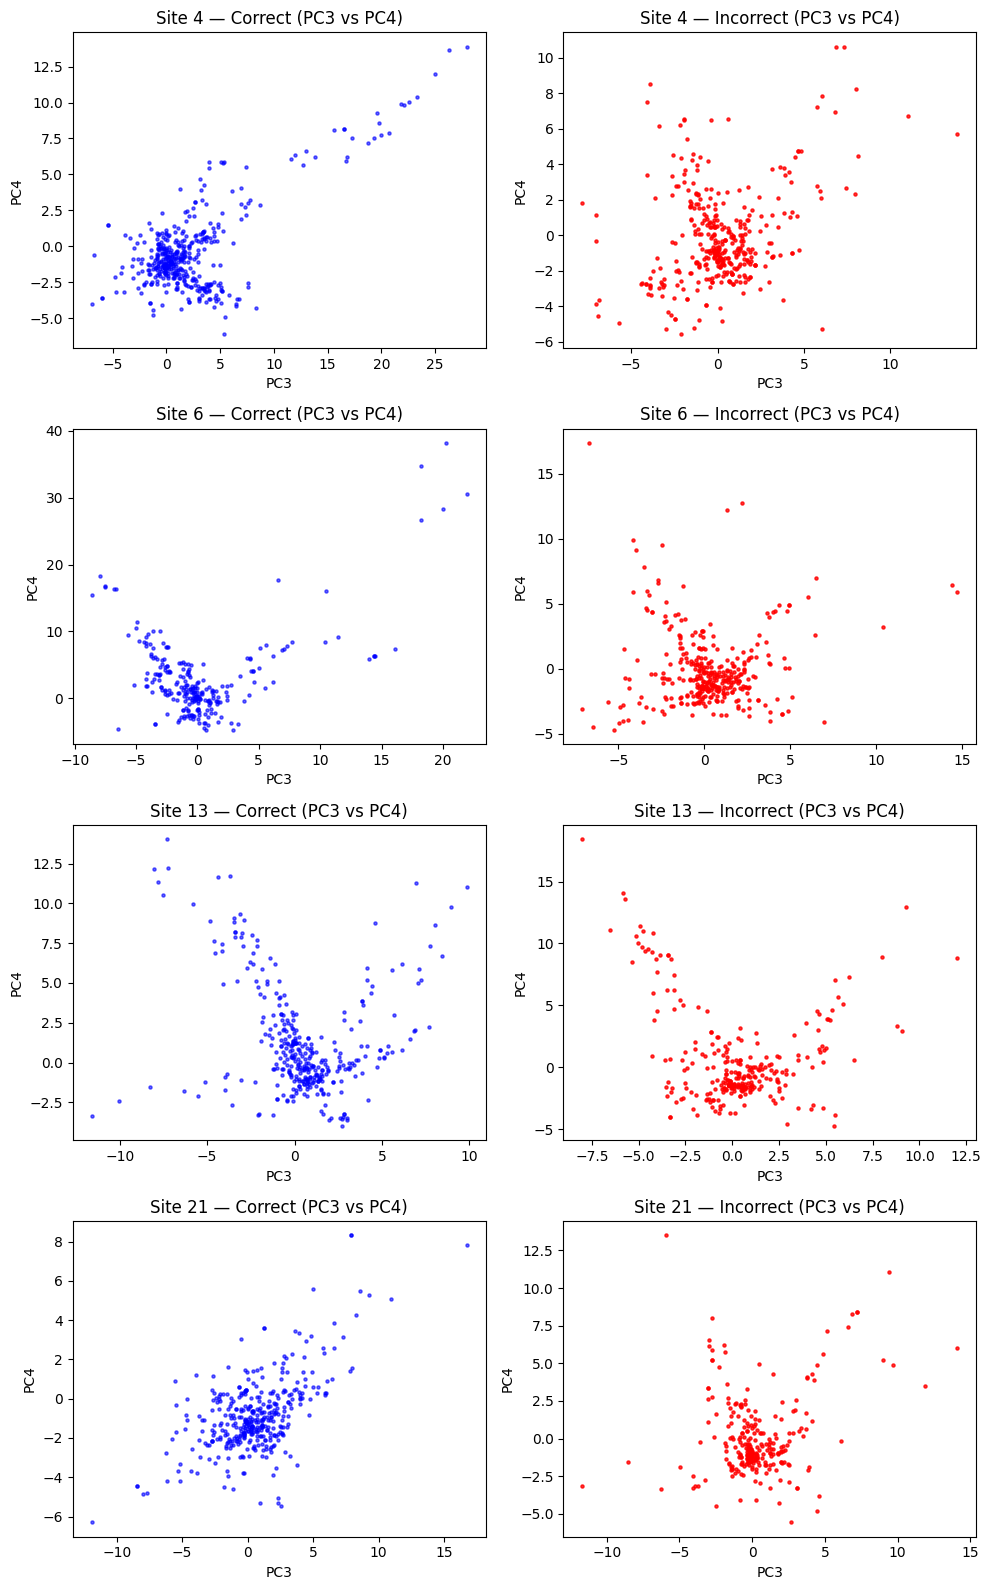

In [32]:
# ─────────────────────────────────────────────────────────────
#  PCA (fit on all sites) — visualize PC3 vs PC4
#  correct / incorrect classification
# ─────────────────────────────────────────────────────────────

cols = 2
rows = len(filtered_site_ids)

plt.figure(figsize=(10, 4 * rows))

for i, cid in enumerate(filtered_site_ids):

    site_mask = labels_filtered == site_to_idx[cid]

    # ---- Correct ----
    plt.subplot(rows, cols, 2*i + 1)
    plt.scatter(
        proj_filtered[site_mask & correct_mask, 2],
        proj_filtered[site_mask & correct_mask, 3],
        s=5,
        color="blue",
        alpha=0.6
    )
    plt.title(f"Site {cid} — Correct (PC3 vs PC4)")
    plt.xlabel("PC3")
    plt.ylabel("PC4")

    # ---- Incorrect ----
    plt.subplot(rows, cols, 2*i + 2)
    plt.scatter(
        proj_filtered[site_mask & incorrect_mask, 2],
        proj_filtered[site_mask & incorrect_mask, 3],
        s=5,
        color="red",
        alpha=0.8
    )
    plt.title(f"Site {cid} — Incorrect (PC3 vs PC4)")
    plt.xlabel("PC3")
    plt.ylabel("PC4")

plt.tight_layout()

plt.savefig(
    "./plots/pca_pc3_pc4_correct_vs_incorrect_allpcbasis.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────
#  Log-Det Complementarity Relative to Site 1
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

epsilon = 1e-3  # regularization strength

# helper function
def logdet_cov(X, eps=1e-3):
    cov = np.cov(X, rowvar=False)
    cov_reg = cov + eps * np.eye(cov.shape[0])
    sign, logdet = np.linalg.slogdet(cov_reg)
    return logdet

# --- get embeddings ---
site_ids = list(site_embeddings.keys())
site_to_idx = {cid: i for i, cid in enumerate(site_ids)}

# baseline = site 1 only
emb_1 = site_embeddings[1].numpy()
logdet_1 = logdet_cov(emb_1, epsilon)

results = []

for cid in site_ids:
    if cid == 1:
        continue

    emb_i = site_embeddings[cid].numpy()

    # union embeddings
    emb_union = np.vstack([emb_1, emb_i])

    logdet_union = logdet_cov(emb_union, epsilon)

    delta = logdet_union - logdet_1

    results.append({
        "site": cid,
        "logdet_union": logdet_union,
        "delta_logdet_relative_to_1": delta
    })

logdet_df = pd.DataFrame(results).sort_values(
    "delta_logdet_relative_to_1", ascending=False
)

logdet_df

,site,logdet_union,delta_logdet_relative_to_1
3,18,-3191.159520,4.413476
1,6,-3192.957488,2.615508
2,13,-3193.286061,2.286934
0,4,-3194.930725,0.642270
4,21,-3194.957750,0.615245


In [15]:
# ─────────────────────────────────────────────────────────────
#  Per-Site Representation Metrics
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

site_ids = list(site_embeddings.keys())

metrics = []

global_mean = all_embs.mean(axis=0)

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid].numpy()
    
    # 1. Cluster Compactness (variance)
    covariance = np.cov(emb, rowvar=False)
    compactness = np.trace(covariance)   # total variance
    
    # 2. Distance to Global Centroid
    site_mean = emb.mean(axis=0)
    centroid_dist = np.linalg.norm(site_mean - global_mean)
    
    # 3. Self Classification Accuracy
    # (from confusion matrix logic)
    mask = labels == i
    y_true = labels[mask]
    y_pred_site = clf.predict(all_embs[mask])
    self_acc = accuracy_score(y_true, y_pred_site)
    
    metrics.append({
        "site": cid,
        "num_samples": emb.shape[0],
        "variance": compactness,
        "centroid_distance": centroid_dist,
        "self_accuracy": self_acc
    })

metrics_df = pd.DataFrame(metrics).sort_values("site")
metrics_df

,site,num_samples,variance,centroid_distance,self_accuracy
0,1,10220,118.790510,0.704335,0.837476
1,4,940,108.208432,1.539207,0.018085
2,6,680,156.662930,2.079241,0.036765
3,13,700,200.992781,2.410880,0.064286
4,18,7640,110.422208,0.824168,0.598560
5,21,700,110.986921,1.274549,0.002857


In [16]:
# ─────────────────────────────────────────────────────────────
#  Composite Valuation Score
# ─────────────────────────────────────────────────────────────

metrics_df["valuation_score"] = (
    metrics_df["centroid_distance"] * metrics_df["self_accuracy"]
)

# Sort descending (higher = more valuable)
valuation_df = metrics_df.sort_values("valuation_score", ascending=False)

# Normalize to [0,1] for easier comparison
min_v = valuation_df["valuation_score"].min()
max_v = valuation_df["valuation_score"].max()

valuation_df["valuation_score_norm"] = (
    (valuation_df["valuation_score"] - min_v) / (max_v - min_v)
)

valuation_df[["site", "centroid_distance", "self_accuracy", "valuation_score", "valuation_score_norm"]]

,site,centroid_distance,self_accuracy,valuation_score,valuation_score_norm
0,1,0.704335,0.837476,0.589863,1.000000
4,18,0.824168,0.598560,0.493314,0.835303
3,13,2.410880,0.064286,0.154985,0.258168
2,6,2.079241,0.036765,0.076443,0.124187
1,4,1.539207,0.018085,0.027837,0.041273
5,21,1.274549,0.002857,0.003642,0.000000


Leave-One-Site-Out Covariance Contribution

In [17]:
# ─────────────────────────────────────────────────────────────
#  Leave-One-Site-Out Variance Contribution
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# global covariance trace
global_cov = np.cov(all_embs, rowvar=False)
global_trace = np.trace(global_cov)

loso_results = []

for i, cid in enumerate(site_ids):
    # Remove this site's embeddings
    mask = labels != i
    embs_minus_i = all_embs[mask]
    
    cov_minus_i = np.cov(embs_minus_i, rowvar=False)
    trace_minus_i = np.trace(cov_minus_i)
    
    delta_trace = global_trace - trace_minus_i
    
    loso_results.append({
        "site": cid,
        "variance_drop": delta_trace
    })

loso_df = pd.DataFrame(loso_results)

# Normalize for readability
min_v = loso_df["variance_drop"].min()
max_v = loso_df["variance_drop"].max()

loso_df["variance_drop_norm"] = (
    (loso_df["variance_drop"] - min_v) / (max_v - min_v)
)

loso_df.sort_values("variance_drop", ascending=False)

,site,variance_drop,variance_drop_norm
3,13,3.010517,1.000000
2,6,1.379132,0.793243
0,1,-0.176843,0.596044
5,21,-0.257598,0.585809
1,4,-0.441306,0.562526
4,18,-4.879841,0.000000
